# Signal types classification

Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий — группе аномальных или неидентифицируемых сигналов.

Студентка: Меньшикова Дарья Александровна

Группа ДПО

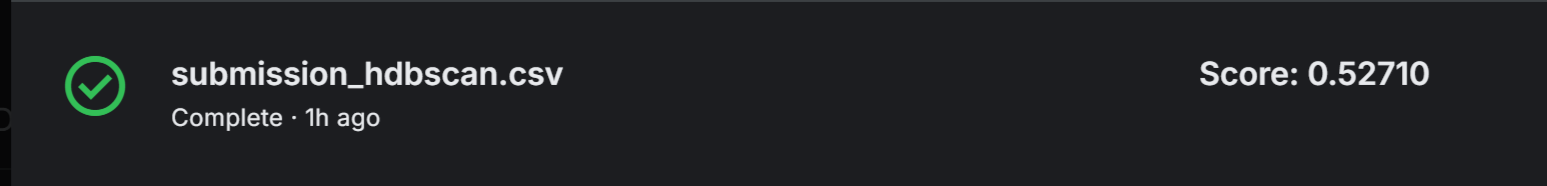

## Подготовка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, peak_widths
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import umap
import os

2026-06-23 18:26:29.269403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782239189.515134     235 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782239189.585919     235 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782239190.184577     235 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782239190.184626     235 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782239190.184629     235 computation_placer.cc:177] computation placer alr

### Исследование и анализ датасета (EDA)

In [2]:
dataset = pd.read_csv("//kaggle/input/competitions/signal-types-classification/Run200_Wave_0_1.txt", sep=' ', header=None, skipinitialspace=True)
# Удаляем метаданные (первые 4 столбца) и лишний 504-й столбец
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
dataset.shape

(23479, 500)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [5]:
print(dataset.duplicated().sum())

0


Text(0, 0.5, 'bit ADC')

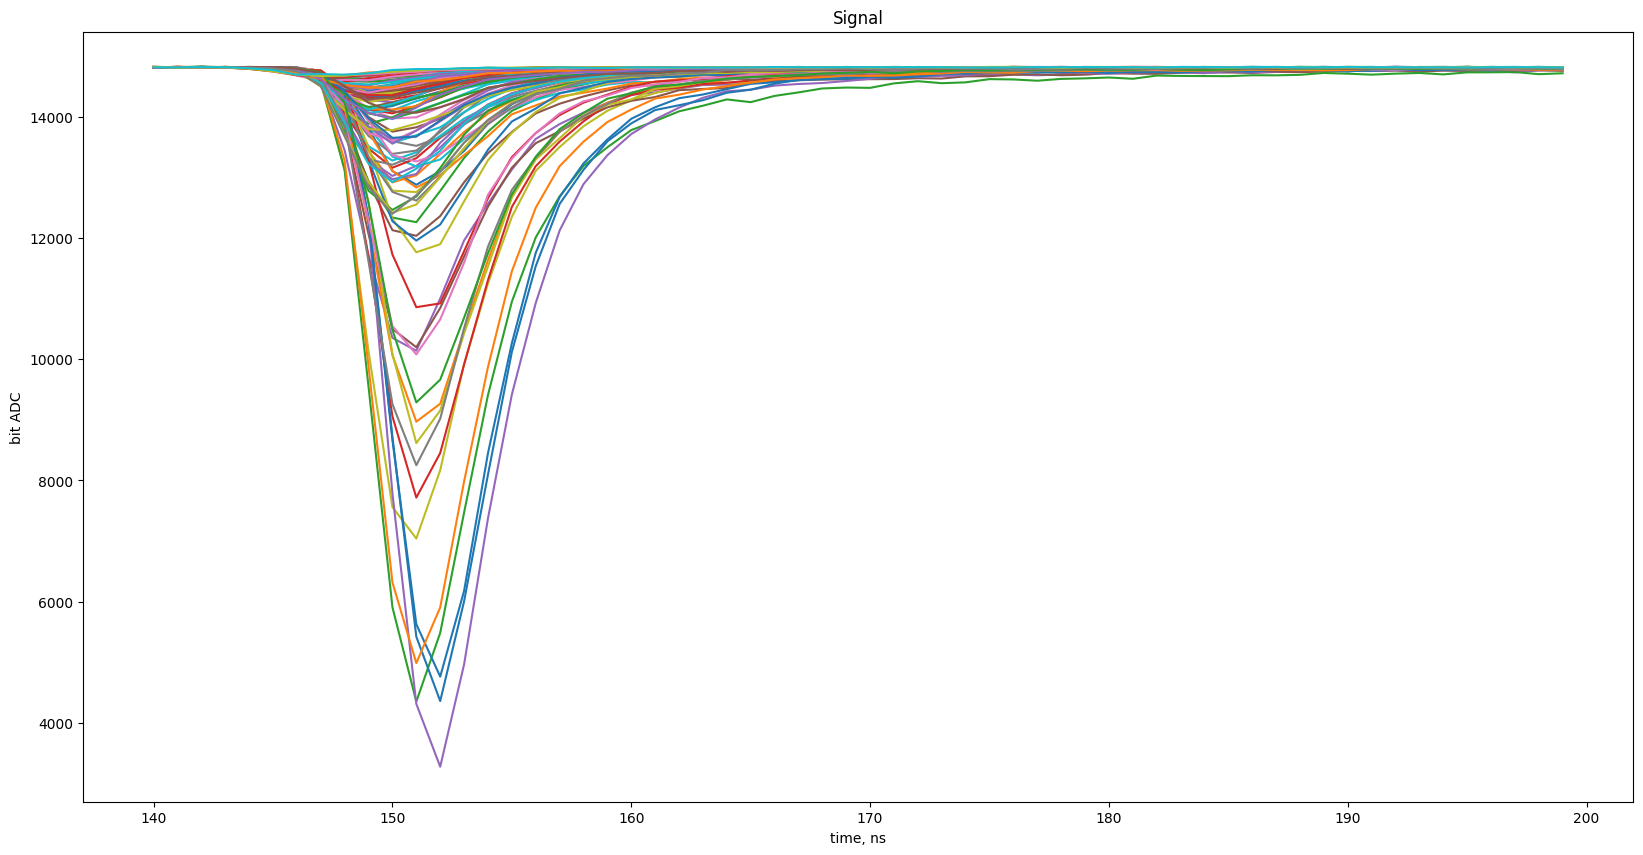

In [6]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

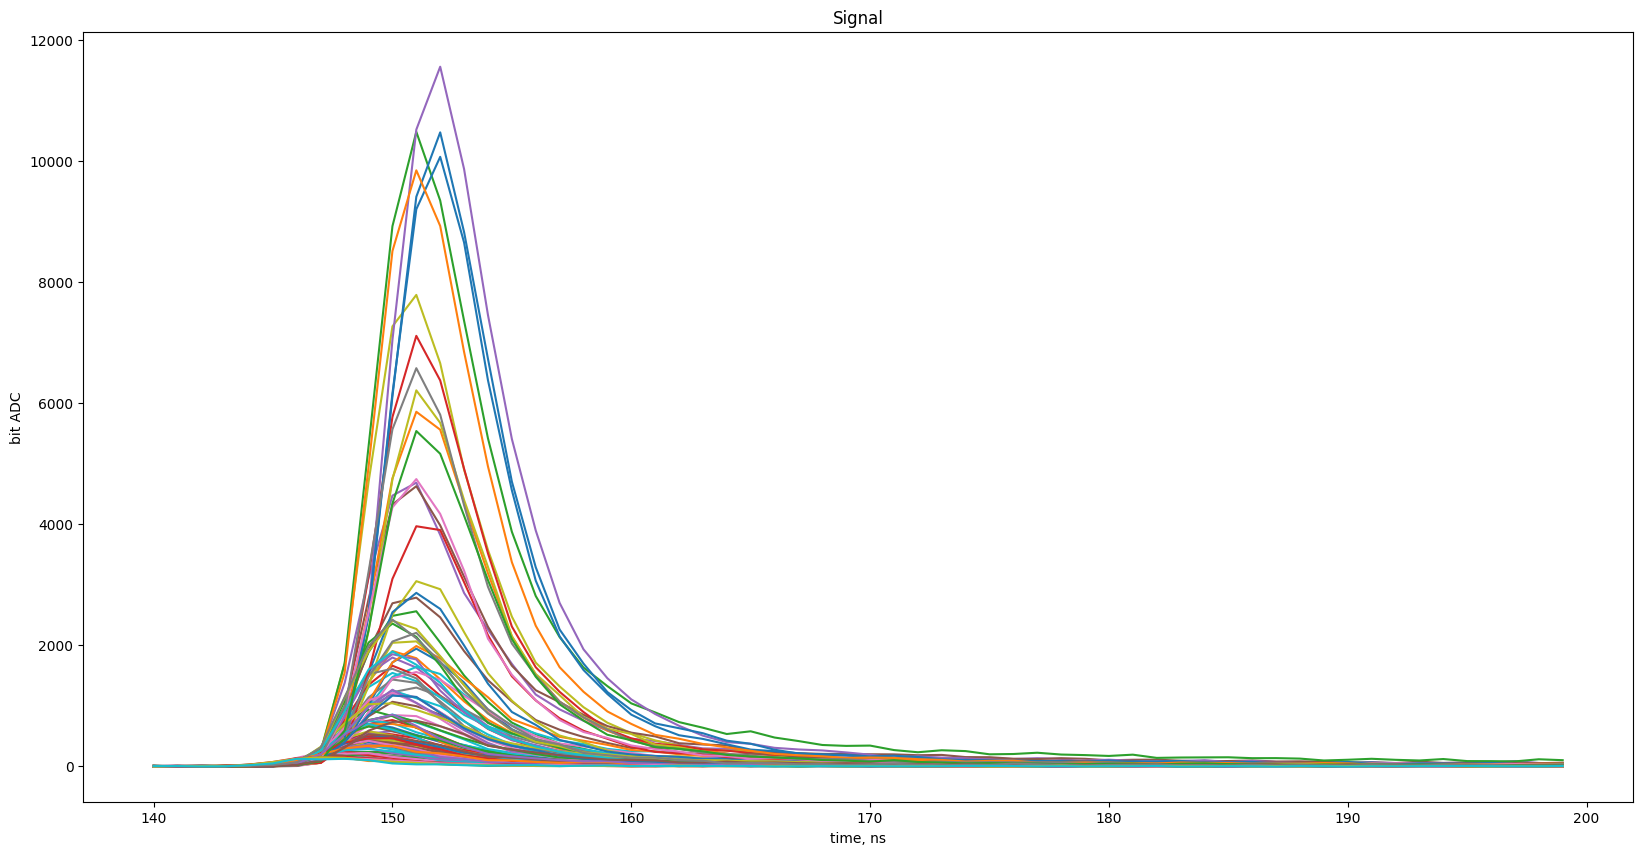

In [7]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


In [8]:
print(f"\nРазмер данных: {dataset.shape}")
print(f"Количество сигналов: {dataset.shape[0]}")
print(f"Количество отсчётов на сигнал: {dataset.shape[1]}")

# Общая статистика по всем данным
total_min = dataset.values.min()
total_max = dataset.values.max()
total_mean = dataset.values.mean()
total_std = dataset.values.std()

print(f"\nГлобальная статистика по всем данным:")
print(f"  Минимум: {total_min:.2f}")
print(f"  Максимум: {total_max:.2f}")
print(f"  Среднее: {total_mean:.2f}")
print(f"  Стандартное отклонение: {total_std:.2f}")


Размер данных: (23479, 500)
Количество сигналов: 23479
Количество отсчётов на сигнал: 500

Глобальная статистика по всем данным:
  Минимум: 0.00
  Максимум: 14838.00
  Среднее: 14796.68
  Стандартное отклонение: 265.92


Загружен датасет, содержащий 23 479 сигналов, каждый из которых представлен 500 временными отсчетами (признаков). 
Пропусков нет.

### Предобработка данных

In [9]:
#инверсия сигнала
#  baseline по первым 50 тактам 
baseline = dataset.iloc[:, :50].mean(axis=1).values.reshape(-1, 1)
signals_inv = baseline - dataset.values

print(f"\nПроверка инверсии:")
print(f"  Средний baseline: {baseline.mean():.2f}")
print(f"  Средний инвертированный шум (первые 50): {signals_inv[:, :50].mean():.2f}")
print(f"  Максимальная амплитуда: {signals_inv.max():.2f}")




Проверка инверсии:
  Средний baseline: 14822.97
  Средний инвертированный шум (первые 50): 0.00
  Максимальная амплитуда: 14824.84


Для улучшения восприятия данных и приведения их к стандартному виду была выполнена инверсия сигналов (вычитание из базовой линии).

In [10]:
# извлечение сигналов
def extract_signal(row, threshold_factor=3):
    noise_mean = row[:50].mean()
    noise_std = row[:50].std()
    threshold = noise_mean + threshold_factor * noise_std
    peak_idx = np.argmax(row)
    
    # Даже если сигнал слабый, мы все равно его сохраним
    if row[peak_idx] < threshold:
        return row[peak_idx:], True
    
    tail = row[peak_idx:]
    below_threshold = np.where(tail < threshold)[0]
    if len(below_threshold) > 0:
        end_idx = peak_idx + below_threshold[0]
    else:
        end_idx = len(row) - 1
    signal = row[peak_idx:end_idx+1]
    
    if len(signal) < 10:
        return row[peak_idx:], True
    
    return signal, False

# Извлекаем ВСЕ сигналы
all_signals = []
anomaly_flags = []

for row in signals_inv:
    sig, is_anom = extract_signal(row)
    all_signals.append(sig)
    anomaly_flags.append(is_anom)

print(f"Всего сигналов: {len(all_signals)}")
print(f"Аномалий: {sum(anomaly_flags)}")

Всего сигналов: 23479
Аномалий: 215


Выполнена инверсия сигналов: из каждого сигнала вычтен его базовый уровень (усредненный по первым 50 отсчетам). Это стандартизировало данные.

### Feature Engineering 

In [11]:
#извлечение признаков
def double_exp_decay(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C

def extract_features(signal):
    try:
        amplitude = signal.max()
        area = np.sum(signal)
        peak_idx = np.argmax(signal)
        length = len(signal)
        
        # FWHM
        half_max = amplitude / 2
        indices_above_half = np.where(signal > half_max)[0]
        fwhm = indices_above_half[-1] - indices_above_half[0] if len(indices_above_half) > 1 else length
        
        # Спад
        decay_start = peak_idx + int(length * 0.1)
        if decay_start >= length:
            decay_start = peak_idx + 1
        decay_part = signal[decay_start:]
        
        try:
            t = np.arange(len(decay_part))
            popt, _ = curve_fit(double_exp_decay, t, decay_part,
                                p0=[decay_part[0]*0.7, 5, decay_part[0]*0.3, 30, 0],
                                maxfev=5000,
                                bounds=([0,1,0,1,0],[np.inf,50,np.inf,200,np.inf]))
            A1, tau1, A2, tau2, C = popt
            ratio_fast_slow = A1 / (A2 + 1e-9)
            return {
                'area': area,
                'amplitude': amplitude,
                'fwhm': fwhm,
                'tau_fast': tau1,
                'tau_slow': tau2,
                'ratio_fast_slow': ratio_fast_slow,
                'length': length
            }
        except:
            return {
                'area': area,
                'amplitude': amplitude,
                'fwhm': fwhm,
                'tau_fast': 0,
                'tau_slow': 0,
                'ratio_fast_slow': 0,
                'length': length
            }
    except:
        return None

# Извлекаем признаки для  сигналов
all_features = []
for sig in all_signals:
    feats = extract_features(sig)
    if feats is not None:
        all_features.append(feats)
    else:
        all_features.append({
            'area': 0, 'amplitude': 0, 'fwhm': 0,
            'tau_fast': 0, 'tau_slow': 0,
            'ratio_fast_slow': 0, 'length': 0
        })

df_features = pd.DataFrame(all_features)
df_features = df_features.fillna(0)
print(f"Признаков: {df_features.shape}")  # (23479, 7)

Признаков: (23479, 7)


In [24]:
df_features.describe()

,area,amplitude,fwhm,tau_fast,tau_slow,ratio_fast_slow,length
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,2.347900e+04,23479.000000
mean,9493.122649,1835.104716,2.667235,2.916419,22.267307,6.617568e+09,43.143107
std,12013.425284,2389.300501,0.696734,1.372141,36.484877,3.669306e+10,41.417780
min,37.740000,104.300000,1.000000,0.000000,0.000000,0.000000e+00,10.000000
25%,1562.550000,308.160000,2.000000,2.096044,5.138151,1.383066e+00,19.000000
50%,4271.720000,812.540000,3.000000,2.826772,10.643474,3.640509e+00,30.000000
75%,12527.520000,2315.050000,3.000000,3.532140,22.674499,1.081009e+01,55.000000
max,95471.900000,14824.840000,8.000000,47.512630,200.000000,8.837691e+11,355.000000


#### выводы:
* area: Сильно асимметричное распределение с длинным правым хвостом — редкие сигналы с огромной площадью.
* amplitude: Сильный разброс (от 104 до 14825), большинство сигналов имеют амплитуду до 2315.
*fwhm: Узкое распределение, большинство сигналов имеют ширину 2–3 отсчёта (редкие выбросы до 8).
* tau_fast: Относительно стабильная быстрая компонента спада (среднее ~2.9, стандартное отклонение 1.4).
* tau_slow: Сильно скошена вправо, есть сигналы с аномально медленным спадом (до 200).
* ratio_fast_slow: Колоссальный разброс (от 0 до 10¹²), требуется логарифмическое преобразование.
* length: Большинство сигналов короткие (медиана 30 отсчётов), но есть хвост до 355.

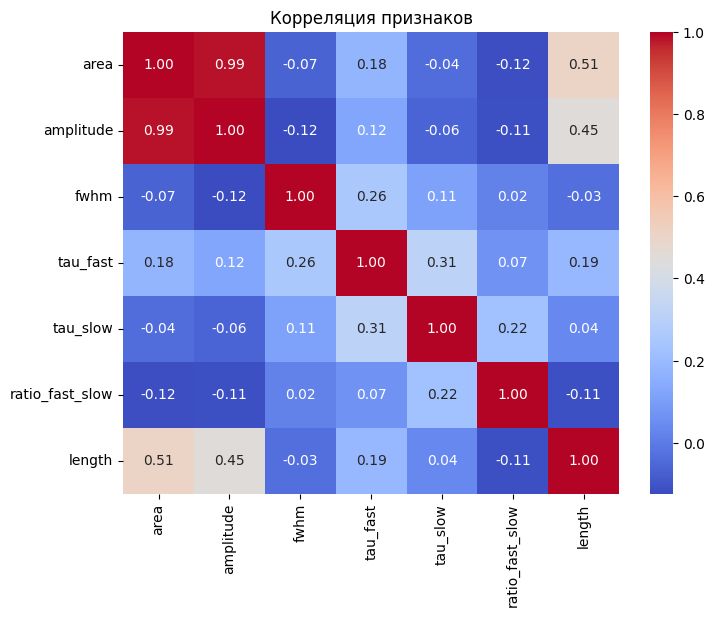

In [20]:
corr = df_features.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

Сильная корреляция между площадью и амплитудой. Для дальнейшего анализа лучше выбрать какой-то один признак.

In [13]:
# подготовка данных для автоенкодера

MAX_LEN = 100
signals_padded = []

for sig in all_signals:
    if len(sig) > MAX_LEN:
        sig = sig[:MAX_LEN]
    else:
        pad_width = MAX_LEN - len(sig)
        sig = np.pad(sig, (0, pad_width), 'constant')
    signals_padded.append(sig)

signals_padded = np.array(signals_padded)
print(f"Форма для автоенкодера: {signals_padded.shape}") 

Форма для автоенкодера: (23479, 100)


Разработана функция для извлечения 7 ключевых признаков (extract_features), таких как площадь, амплитуда, FWHM и параметры двуэкспоненциального спада (быстрая и медленная компоненты).

Для 215 сигналов (0.9%) не удалось построить модель, они были отмечены как потенциальные аномалии.

Сверточные слои идеально подходят для временных рядов, так как они улавливают локальные паттерны.

In [14]:
# сверточный автоенкодер

input_signal = layers.Input(shape=(MAX_LEN, 1))

# Encoder
x = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(input_signal)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
x = layers.GlobalMaxPooling1D()(x)
encoded = layers.Dense(32, activation='relu')(x)

# Decoder
d = layers.Dense(128, activation='relu')(encoded)
d = layers.Reshape((1, 128))(d)
d = layers.UpSampling1D(size=25)(d)
d = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(d)
d = layers.UpSampling1D(size=2)(d)
d = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(d)
d = layers.UpSampling1D(size=2)(d)
decoded = layers.Conv1D(1, kernel_size=5, activation='linear', padding='same')(d)

autoencoder = Model(input_signal, decoded)
encoder = Model(input_signal, encoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Обучение
print("Обучение автоенкодера")
autoencoder.fit(signals_padded.reshape(-1, MAX_LEN, 1),
                signals_padded.reshape(-1, MAX_LEN, 1),
                epochs=50, batch_size=256, validation_split=0.2, verbose=1)

# Получаем признаки из автоенкодера
X_ae = encoder.predict(signals_padded.reshape(-1, MAX_LEN, 1), verbose=0)
print(f"Признаки автоенкодера: {X_ae.shape}")

2026-06-23 18:38:01.433052: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Обучение автоенкодера
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 36965.3359 - val_loss: 2036.7557
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 1806.1669 - val_loss: 1507.6633
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 1443.0502 - val_loss: 1288.2832
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 1693.8491 - val_loss: 1338.8910
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 1103.5319 - val_loss: 875.0925
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 826.2575 - val_loss: 733.7159
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 752.9620 - val_loss: 679.8329
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 678.4727 - val_loss: 932.7819
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 1001.0215 - val_loss: 613.3464
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 583.4323 - val_loss: 562.0196
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 561.2835 - val_

Сигналы были приведены к единой длине (100 отсчетов) с помощью дополнения нулями (padding).

Обучен сверточный автоенкодер, который эффективно сжимает сигналы до 32-мерного латентного пространства (X_ae). Это позволяет извлечь сложные, нелинейные паттерны сигналов.

Потери на валидации стабилизировались на уровне ~502, что говорит об успешном обучении модели без переобучения.

In [15]:
# нормализация и umap
 
# Нормализация классических признаков
scaler = StandardScaler()
X_classic = scaler.fit_transform(df_features)

# UMAP для уменьшения размерности признаков автоенкодера
reducer = umap.UMAP(n_components=20, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_ae)
print(f"UMAP признаки: {X_umap.shape}")

# Комбинирование признаков
X_final = np.hstack([X_classic, X_umap])
print(f"Финальные признаки: {X_final.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP признаки: (23479, 20)
Финальные признаки: (23479, 27)


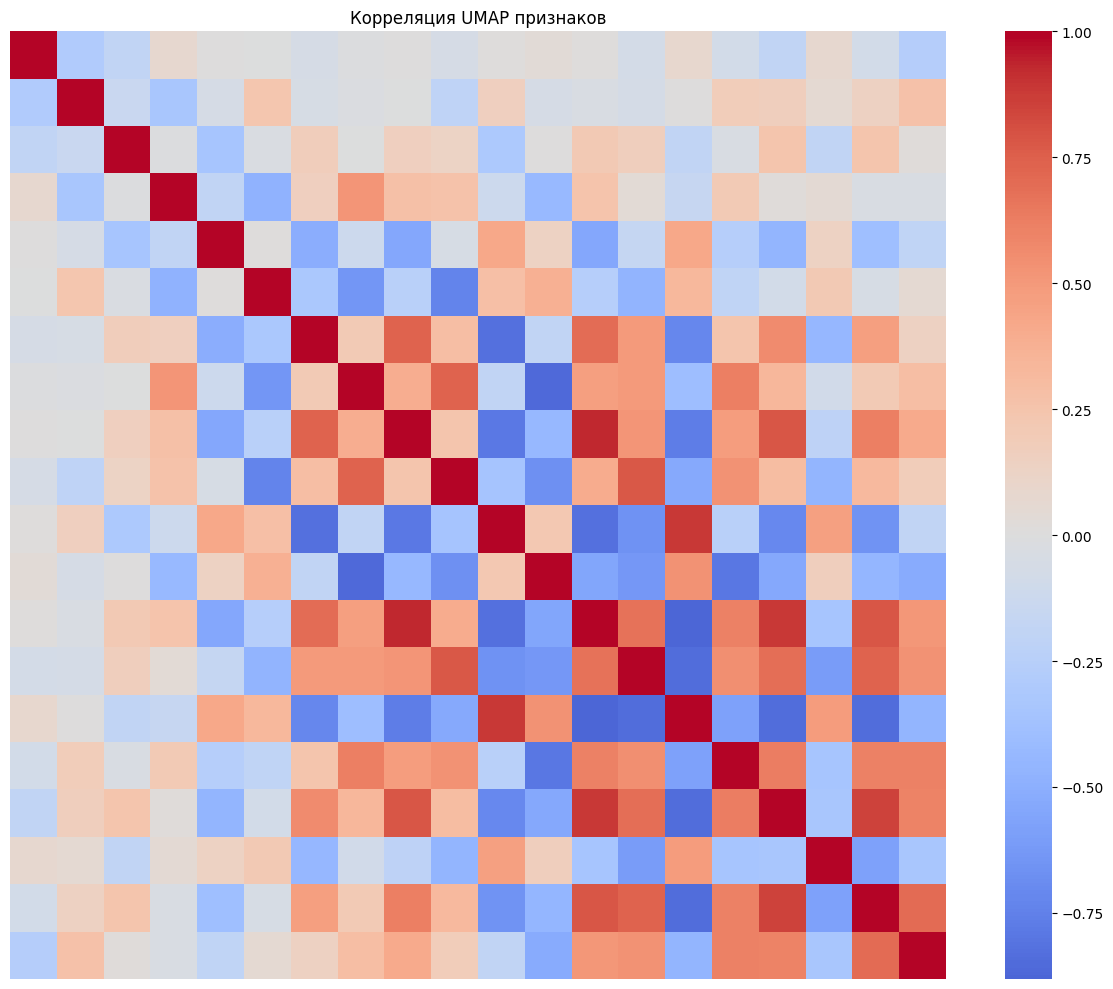

Количество пар с корреляцией > 0.5: 134


In [16]:
# анализ корреляции umap признаков

# Матрица корреляции для UMAP признаков
df_umap = pd.DataFrame(X_umap)
df_umap.columns = [f'umap_{i}' for i in range(X_umap.shape[1])]

plt.figure(figsize=(12, 10))
corr_matrix = df_umap.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title('Корреляция UMAP признаков')
plt.tight_layout()
plt.show()

# Количество сильных корреляций
strong_corr = np.sum(np.abs(corr_matrix.values) > 0.5)
print(f"Количество пар с корреляцией > 0.5: {strong_corr}")

Нормализация: Классические признаки были стандартизированы (масштабированы) для приведения к одному диапазону.

Снижение размерности: Для 32 признаков автоенкодера был применен метод UMAP, снизивший размерность до 20 компонент. Это позволило сжать информацию, сохранив глобальную структуру данных.

Финальные признаки: Получен итоговый массив X_final размером (23479, 27), объединяющий 7 классических и 20 UMAP-признаков.

Анализ корреляции: Проверка показала наличие 134 пар с высокой корреляцией (>0.5), что указывает на некоторую избыточность в UMAP-признаках.

### Обучение моделей

In [21]:
# кластеризация

# HDBSCAN
clusterer_hdbscan = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, prediction_data=True)
labels_hdbscan = clusterer_hdbscan.fit_predict(X_final)
print(f"HDBSCAN уникальные метки: {np.unique(labels_hdbscan)}")
print(f"HDBSCAN аномалий: {np.sum(labels_hdbscan == -1)}")

# K-Means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_final)
print(f"K-Means распределение: {np.bincount(labels_kmeans)}")

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_final)
print(f"Agglomerative распределение: {np.bincount(labels_agg)}")

# Метрики качества кластеризации
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, name):
    if len(set(labels)) < 2:
        return
    print(f"\n{name}:")
    print(f"  Silhouette: {silhouette_score(X, labels):.4f}")
    print(f"  Calinski-Harabasz: {calinski_harabasz_score(X, labels):.2f}")
    print(f"  Davies-Bouldin: {davies_bouldin_score(X, labels):.4f}")

# K-Means
evaluate_clustering(X_final, labels_kmeans, "K-Means")

# Agglomerative
evaluate_clustering(X_final, labels_agg, "Agglomerative")

# HDBSCAN (только не-аномалии)
mask = labels_hdbscan != -1
evaluate_clustering(X_final[mask], labels_hdbscan[mask], "HDBSCAN (без аномалий)")

HDBSCAN уникальные метки: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12]
HDBSCAN аномалий: 1788
K-Means распределение: [9602 6897 6980]
Agglomerative распределение: [12115  6941  4423]

K-Means:
  Silhouette: 0.3585
  Calinski-Harabasz: 9372.51
  Davies-Bouldin: 1.3109

Agglomerative:
  Silhouette: 0.3487
  Calinski-Harabasz: 8604.20
  Davies-Bouldin: 1.2803

HDBSCAN (без аномалий):
  Silhouette: -0.1426
  Calinski-Harabasz: 416.45
  Davies-Bouldin: 1.9301


K-Means сформировал 3 сбалансированных кластера с наибольшим значением Silhouette Score (0.3585), что указывает на наилучшую внутреннюю согласованность.

Agglomerative показал похожие результаты (Silhouette: 0.3487).

HDBSCAN выделил множество мелких кластеров (14) и большое количество аномалий (1788), что привело к отрицательному Silhouette Score (-0.1426). 

In [22]:
#  результаты для всех трех моделей

def save_submission(labels, name, anomaly_label=-1):
    """Сохраняет предсказания в CSV с именем модели"""
    labels = prepare_submission(labels, anomaly_label)
    
    submission = pd.DataFrame({
        'index': np.arange(len(labels)),
        'cluster': labels
    })
    
    filename = f'submission_{name}.csv'
    submission.to_csv(filename, index=False)
    
    print(f"\n{name}:")
    print(f"  Распределение: {np.bincount(labels)}")
    print(f"  Кластер 0: {np.sum(labels == 0)}")
    print(f"  Кластер 1: {np.sum(labels == 1)}")
    print(f"  Кластер 2: {np.sum(labels == 2)}")
    print(f"  Сохранено: {filename}")

# Сохраняем все три модели
save_submission(labels_kmeans, 'kmeans')
save_submission(labels_agg, 'agglomerative')
save_submission(labels_hdbscan, 'hdbscan')

print("\n✅ Все результаты сохранены!")


kmeans:
  Распределение: [9602 6897 6980]
  Кластер 0: 9602
  Кластер 1: 6897
  Кластер 2: 6980
  Сохранено: submission_kmeans.csv

agglomerative:
  Распределение: [12115  6941  4423]
  Кластер 0: 12115
  Кластер 1: 6941
  Кластер 2: 4423
  Сохранено: submission_agglomerative.csv

hdbscan:
  Распределение: [10015  8427  3252   475   301   214   161   131   120   111   107   106
    59]
  Кластер 0: 10015
  Кластер 1: 8427
  Кластер 2: 3252
  Сохранено: submission_hdbscan.csv

✅ Все результаты сохранены!
